# Problem Set #3

Mariajosé Argote, Felipe Manzi, and Xiaoyan Wang

# Question 1

Part (a)

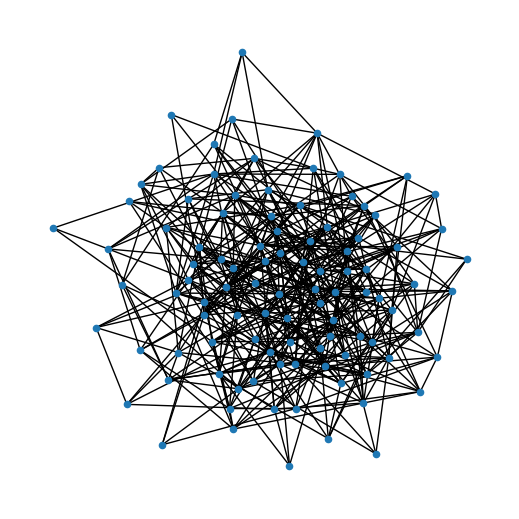

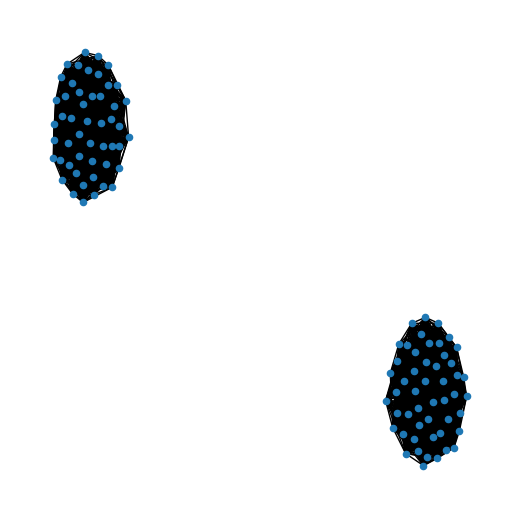

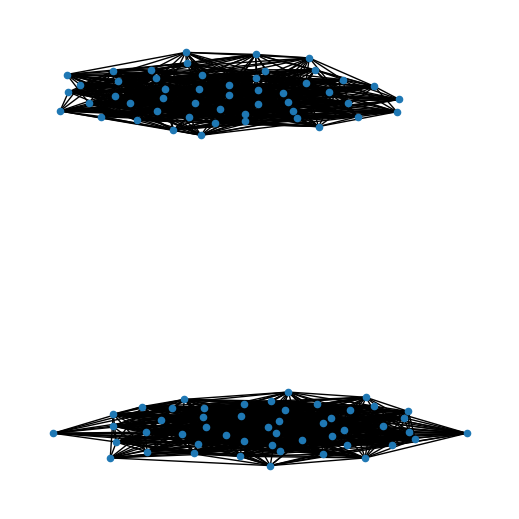

In [12]:
import math
import random
import networkx as nx
import matplotlib.pyplot as plt

n = 100 #population size
c = 2 #number of communities
d = 10 #average degree
epsilon = {0,4,8} #strength of communities

def generate_sbm(n, c, d, epsilon):
    p_in = d / n * (1 + epsilon / (c - 1)) #probability of connection within communities
    p_out = d / n * max(0,1 - epsilon / (c - 1)) #probability of connection between communities, has to be capped
    # at zero because otherwise it gives us negative probabilities when epsilon is large
    
    sizes = [n // c] * c #double // is to ensure we get an integer number of nodes in each community
    probs = [[p_in if i == j else p_out for j in range(c)] for i in range(c)]
    
    G = nx.stochastic_block_model(sizes, probs)
    return G

# function to plot the three graphs
def plot_graph(G):
    pos = nx.spring_layout(G) #use shell layout for better visualization
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, node_size=20, with_labels=False)
    plt.show()

# generate and plot the three graphs
for eps in epsilon:
    G = generate_sbm(n, c, d, eps)
    plot_graph(G)